In [3]:
import numpy as np
import pandas as pd

df = pd.read_csv("./practica/sensores.csv")

# Sumamos una columna de turno, para tener categorías con las que comparar en la sección de barras
df["hora_del_dia"] = df.index % 24
df["turno"] = pd.cut(
    df["hora_del_dia"],
    bins=[-1, 7, 15, 23],
    labels=["Noche", "Mañana", "Tarde"]
)

df.head()

,temperatura,presion,consumo_kwh,produccion,eficiencia,hora_del_dia,turno
0,79.0,98.5,174.9,145.7,83.7,0,Noche
1,73.9,93.3,144.1,125.6,85.9,1,Noche
2,80.2,108.0,178.8,151.8,85.2,2,Noche
3,87.2,116.4,199.4,159.2,81.5,3,Noche
4,73.1,95.0,158.5,133.2,84.2,4,Noche


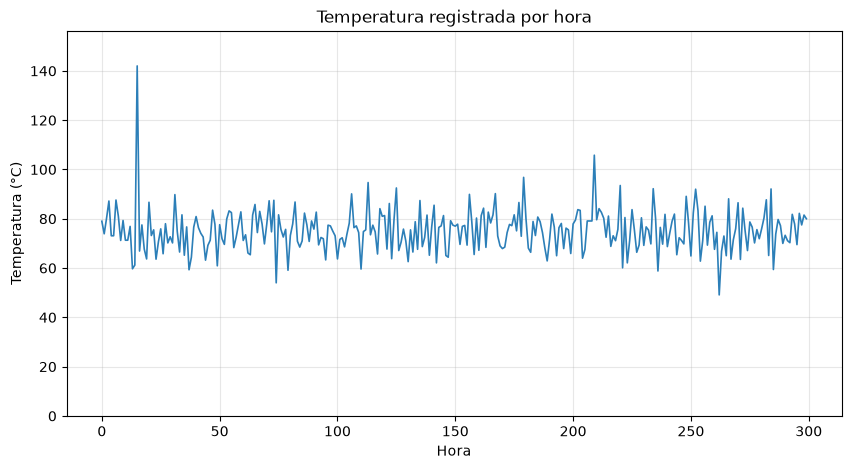

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df["temperatura"], color="#2c7fb8", linewidth=1.2)
ax.set_title("Temperatura registrada por hora")
ax.set_xlabel("Hora")
ax.set_ylabel("Temperatura (°C)")
ax.set_ylim(0, df["temperatura"].max() * 1.1)
ax.grid(alpha=0.3)
plt.show()

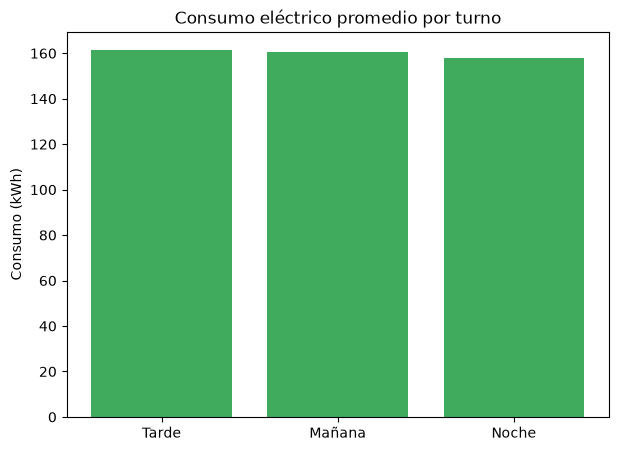

In [6]:
consumo_por_turno = df.groupby("turno", observed=True)["consumo_kwh"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(consumo_por_turno.index, consumo_por_turno.values, color="#41ab5d")
ax.set_title("Consumo eléctrico promedio por turno")
ax.set_ylabel("Consumo (kWh)")
plt.show()

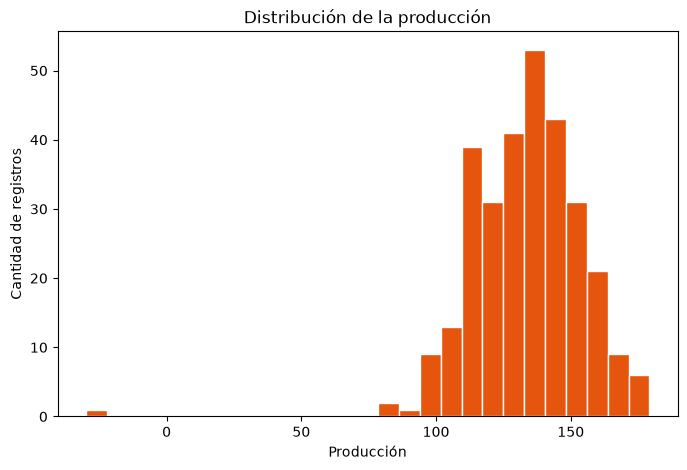

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["produccion"], bins="fd", color="#e6550d", edgecolor="white")
ax.set_title("Distribución de la producción")
ax.set_xlabel("Producción")
ax.set_ylabel("Cantidad de registros")
plt.show()

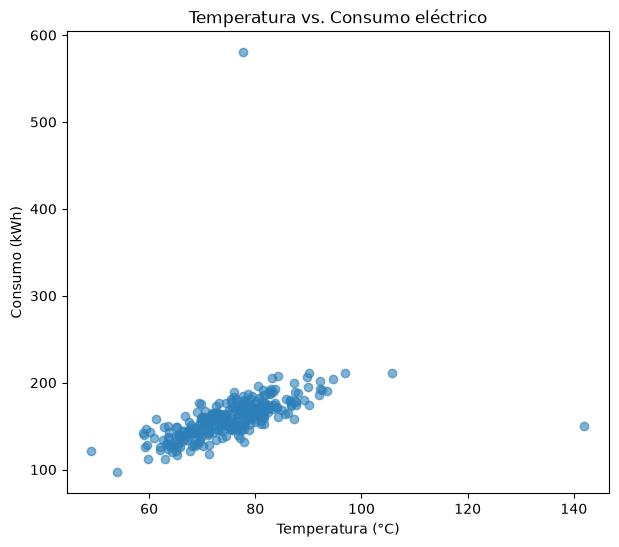

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["temperatura"], df["consumo_kwh"], alpha=0.6, color="#2c7fb8")
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Consumo (kWh)")
ax.set_title("Temperatura vs. Consumo eléctrico")
plt.show()

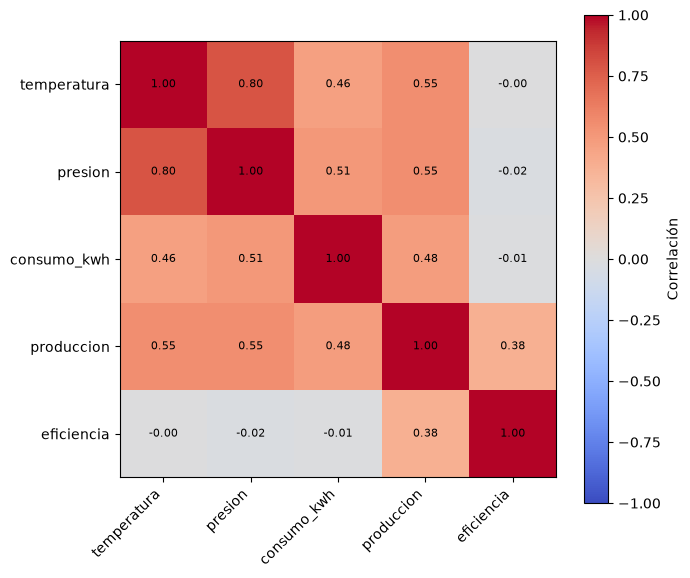

In [9]:
columnas_numericas = ["temperatura", "presion", "consumo_kwh", "produccion", "eficiencia"]
matriz_corr = df[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matriz_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas_numericas)))
ax.set_yticks(range(len(columnas_numericas)))
ax.set_xticklabels(columnas_numericas, rotation=45, ha="right")
ax.set_yticklabels(columnas_numericas)
fig.colorbar(im, label="Correlación")

for i in range(len(columnas_numericas)):
    for j in range(len(columnas_numericas)):
        ax.text(j, i, f"{matriz_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()